# Hubungan Diskon terhadap Volume Penjualan

## Metodologi

1. Memfilter data pada kategori Teknologi di bulan April.
2. Menghitung `quantity` untuk setiap tingkat diskon.
3. Memvisualisasikan volume penjualan per tingkat diskon.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

df = pd.read_csv('superstore_2017.csv')

## Filter Data pada Kategori Teknologi di Bulan April

Analisis difokuskan pada kategori Teknologi sebagai kategori yang mengalami kerugian pada bulan April.

In [2]:
df_tech = df[(df['order_month'] == 'April') & (df['category'] == 'Technology')]

## Hitung Quantity per Tingkat Diskon

Data dikelompokkan berdasarkan `discount`, kemudian `quantity` dihitung untuk setiap tingkat diskon.

In [3]:
df_agg = df_tech.pivot_table(index='discount', values='quantity', aggfunc='sum').astype(int)

df_agg

,quantity
discount,
0.0,38
20.0,39
40.0,8
70.0,5


## Visualisasi Volume Penjualan per Tingkat Diskon

Menampilkan `quantity` per tingkat diskon pada kategori Teknologi untuk menganalisis apakah peningkatan diskon diikuti oleh peningkatan volume penjualan.

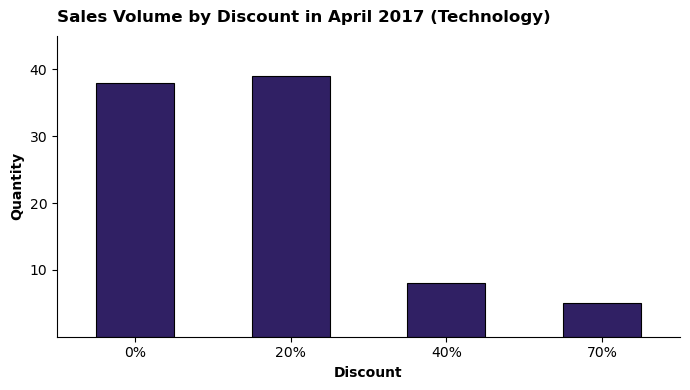

In [4]:
plt.figure(figsize=(7,4))
fig = sns.barplot(x=df_agg.index, y=df_agg['quantity'], color='#2A1470', ls='-', lw=0.8, ec='black', alpha=1)

for bar in fig.patches:
    bar.set_width(0.5)
    bar.set_xy((bar.get_xy()[0] + 0.15, 0))

title_dict = {'size':12,
              'weight':'bold',
              'color':'black',
              'loc':'left',
              'rotation':0,
              'pad':10,
              'alpha':1,
              'family':plt.rcParams['font.family']}

label_dict = {'x':
              {'size':10,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':0,
              'alpha':1,
              'family':plt.rcParams['font.family']},
              
              'y':
              {'size':10,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':90,
              'alpha':1,
              'family':plt.rcParams['font.family']}}    

plt.title('Sales Volume by Discount in April 2017 (Technology)', **title_dict)
plt.xlabel('Discount', **label_dict['x'])
plt.ylabel('Quantity', **label_dict['y'])

ax = plt.gca()
ticks = ax.get_xticks()
labels = [f'{discount:.0f}%' for discount in df_agg.index]
ax.set_xticks(ticks=ticks, labels=labels)
ax.set_yticks(ticks=ax.get_yticks()[2:-1:2])
ax.set_ylim(0, 45)

plt.tight_layout()
sns.despine(left=False, top=True, right=True, bottom=False)
plt.show()